# Dự đoán giá phòng trọ bằng học máy


## 1. Giới thiệu bài toán

Dự đoán giá phòng trọ dựa trên các đặc trưng như:

* Diện tích
* Nội thất (có/không)
* Quận
* Thành phố

## 2. Feature Engineering

- Biến phân loại (quận, thành phố) được **target encoding** bằng giá trung bình tại từng khu vực (chỉ fit trên tập train của mỗi fold).
- Biến nhị phân nội thất được **One-Hot Encoding**.
- Loại bỏ các dòng bị thiếu dữ liệu và xử lý outlier cơ bản (upper-bound)

## 3. Chia tập dữ liệu và trực quan hóa phân phối
Dữ liệu được chia thành 2 tập: 
- **Tập huấn luyện + xác thực (train+val):** 80% tổng số mẫu.
- **Tập kiểm thử (test):** 20% tổng số mẫu, chỉ dùng để đánh giá cuối cùng.

### Trực quan hóa phân phối giá phòng trên các tập con
Biểu đồ dưới đây giúp kiểm tra sự tương đồng về phân phối giá phòng giữa các tập con.

In [62]:
# plt.figure(figsize=(12,5))
# plt.subplot(1,2,1)
# sns.histplot(y_trainval, color='blue', label='Train+Val', kde=True, stat='density', alpha=0.6)
# sns.histplot(y_test, color='red', label='Test', kde=True, stat='density', alpha=0.6)
# plt.legend()
# plt.title('Histogram phân phối giá phòng')
# plt.xlabel('Giá phòng')

# plt.subplot(1,2,2)
# sns.boxplot(data=[y_trainval, y_test], palette=['blue', 'red'])
# plt.xticks([0,1], ['Train+Val', 'Test'])
# plt.title('Boxplot phân phối giá phòng')
# plt.ylabel('Giá phòng')
# plt.tight_layout()
# plt.show()

In [ ]:
# import các thư viện cần thiết
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

df = pd.read_csv('clean_data.csv')
X = df[['Area', 'nội thất', 'District_encode', 'City_encode']]
y = df['Price']

# Chia dữ liệu: 80% train+val, 20% test
X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Kích thước của tập huấn luyện + xác thực:", X_trainval.shape)
print("Kích thước của tập kiểm tra:", X_test.shape)


Kích thước của tập huấn luyện + xác thực: (844, 4)
Kích thước của tập kiểm tra: (212, 4)


### 3.2 Các mô hình tiến hành
Nhóm trình bày 2 mô hình

1. **Mô hình Random Forest Regressor**
    - Siêu tham số: n_estimators=100, max_depth=10, random_state=42
    - Hàm loss: MSE
2. **Mô hình Gradient Boosting Regressor**
    - Siêu tham số: learning_rate=0.1, max_depth=3, n_estimators=50, random_state=42
    - Hàm loss: MSE

### 3.3 Kĩ thuật lựa chọn mô hình
Để lựa chọn mô hình tốt nhất cho bài toán dự đoán giá phòng trọ, nhóm tiến hành như sau:

1. **Mô hình thử nghiệm:**
   - Random Forest Regressor
   - XGBoost Regressor

2. **Kỹ thuật đánh giá:**
   - Dùng **K-Fold Cross Validation** với `k=5` trên tập huấn luyện + xác thực (80%)
   - Mỗi mô hình được huấn luyện và đánh giá 5 lần trên các fold

3. **Metric so sánh:**
   - RMSE (Root Mean Squared Error)
   - MAE (Mean Absolute Error)
   - R² Score

4. **Tiêu chí chọn mô hình:**
   - Mô hình có **RMSE trung bình thấp nhất** trên các fold
   - Kèm theo đánh giá độ ổn định qua phương sai của các metric

## 4. Huấn luyện mô hình
### 4.1 Random Forest Regressor


In [64]:
# from sklearn.model_selection import KFold
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# import category_encoders as ce

# kf = KFold(n_splits=5, shuffle=True, random_state=42)

# rmses, maes, r2s = [], [], []

# for train_index, val_index in kf.split(X_trainval):
#     X_train, X_val = X_trainval.iloc[train_index].copy(), X_trainval.iloc[val_index].copy()
#     y_train, y_val = y_trainval.iloc[train_index], y_trainval.iloc[val_index]

#     # Target Encoding (chỉ fit trên tập train của fold)
#     encoder = ce.TargetEncoder(cols=['City_encode', 'District_encode'])
#     X_train[['City_encode', 'District_encode']] = encoder.fit_transform(X_train[['City_encode', 'District_encode']], y_train)
#     X_val[['City_encode', 'District_encode']] = encoder.transform(X_val[['City_encode', 'District_encode']])

#     # Train model
#     model = RandomForestRegressor(learning_rate=0.1, n_estimators=50, max_depth=3, random_state=42)
#     model.fit(X_train, y_train)

#     # Predict + Evaluate
#     y_pred = model.predict(X_val)
#     rmses.append(np.sqrt(mean_squared_error(y_val, y_pred)))
#     maes.append(mean_absolute_error(y_val, y_pred))
#     r2s.append(r2_score(y_val, y_pred))

# print(f'Kết quả K-Fold CV (Random Forest):')
# print(f'RMSE trung bình: {np.mean(rmses):.4f}')
# print(f'MAE trung bình: {np.mean(maes):.4f}')
# print(f'R2 trung bình: {np.mean(r2s):.4f}')

### 4.2 Gradient Boosting Regressor

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Đọc dữ liệu
df = pd.read_csv('clean_data.csv')

# Tách đặc trưng và nhãn, giữ lại District và City để mã hóa
X = df[['Area', 'nội thất', 'District', 'City', "thang máy", "tủ lạnh"]]
y = df['Price']

# Chia dữ liệu: 80% train+val, 20% test
X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# KFold CV
kf = KFold(n_splits=5, shuffle=True, random_state=42)
rmses, maes, r2s = [], [], []

for train_index, val_index in kf.split(X_trainval):
    X_train = X_trainval.iloc[train_index].copy()
    X_val = X_trainval.iloc[val_index].copy()
    y_train = y_trainval.iloc[train_index]
    y_val = y_trainval.iloc[val_index]

    # Tính trung bình giá theo District và City trong tập train
    temp = X_train.copy()
    temp["Price"] = y_train

    district_avg = temp.groupby("District")["Price"].mean().to_dict()
    city_avg = temp.groupby("City")["Price"].mean().to_dict()

    # Mã hóa trung bình, điền NaN nếu có giá trị mới
    X_train["District_encode"] = X_train["District"].map(district_avg).fillna(0)
    X_val["District_encode"] = X_val["District"].map(district_avg).fillna(0)

    X_train["City_encode"] = X_train["City"].map(city_avg).fillna(0)
    X_val["City_encode"] = X_val["City"].map(city_avg).fillna(0)

    # Chọn các feature số để train
    features = ["Area", "nội thất", "District_encode", "City_encode", "thang máy", "tủ lạnh", ]

    # Huấn luyện mô hình
    model = GradientBoostingRegressor(
        n_estimators=50,
        learning_rate=0.1,
        max_depth=3,
        loss='squared_error',
        random_state=42
    )

    model.fit(X_train[features], y_train)

    # Dự đoán và đánh giá
    y_pred = model.predict(X_val[features])
    rmses.append(np.sqrt(mean_squared_error(y_val, y_pred)))
    maes.append(mean_absolute_error(y_val, y_pred))
    r2s.append(r2_score(y_val, y_pred))

# In kết quả trung bình
print('Kết quả K-Fold CV (Gradient Boosting Regressor):')
print(f'RMSE trung bình: {np.mean(rmses):.4f}')
print(f'MAE trung bình: {np.mean(maes):.4f}')
print(f'R2 trung bình: {np.mean(r2s):.4f}')


Kết quả K-Fold CV (Gradient Boosting Regressor):
RMSE trung bình: 0.7797
MAE trung bình: 0.5888
R2 trung bình: 0.5706


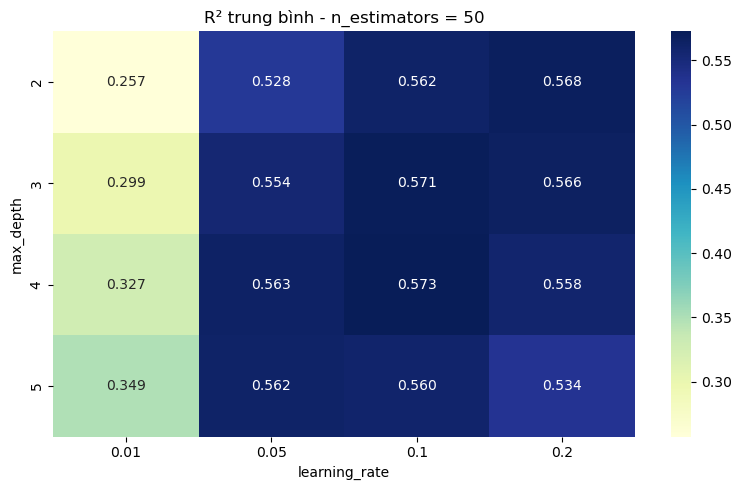

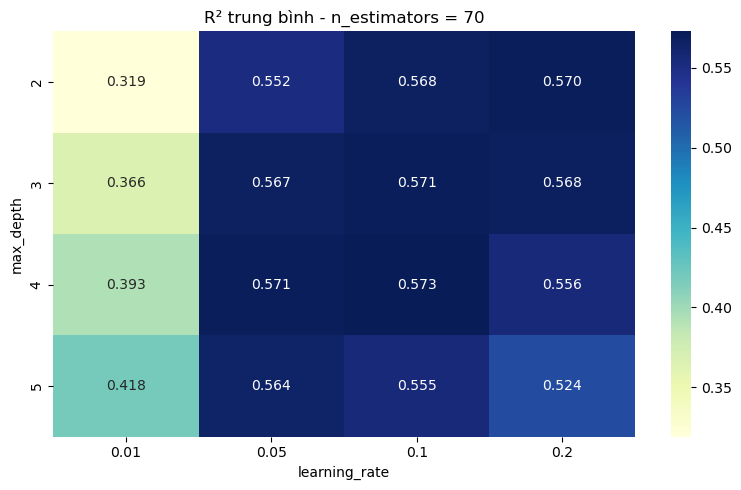

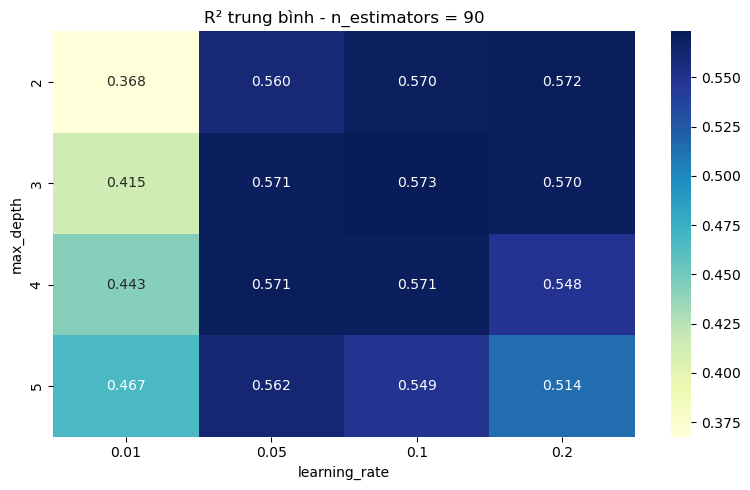

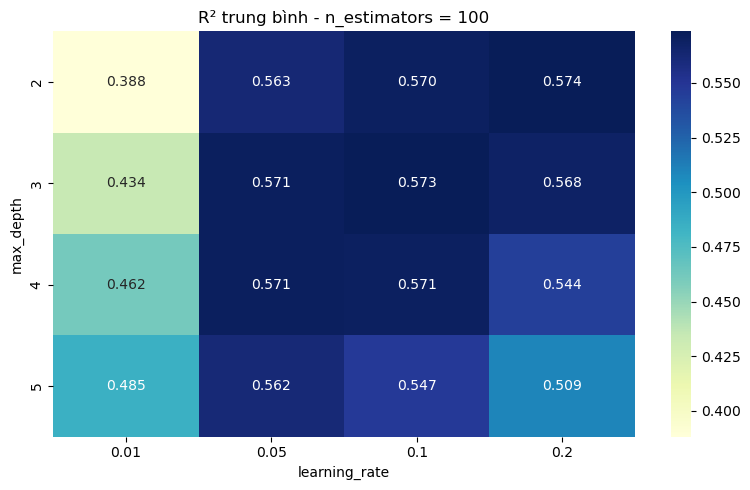

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score

# Đọc dữ liệu
df = pd.read_csv('clean_data.csv')
X = df[['Area', 'nội thất', 'District', 'City', "Time_Post", "thang máy", "tủ lạnh"]]
y = df['Price']

# Chia dữ liệu
X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Tập giá trị thử nghiệm
n_estimators_list = [50, 70, 90, 100]
learning_rates = [0.01, 0.05, 0.1, 0.2]
max_depths = [2, 3, 4, 5]

results = []

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for n in n_estimators_list:
    for lr in learning_rates:
        for depth in max_depths:
            r2_scores = []

            for train_idx, val_idx in kf.split(X_trainval):
                X_train = X_trainval.iloc[train_idx].copy()
                X_val = X_trainval.iloc[val_idx].copy()
                y_train = y_trainval.iloc[train_idx]
                y_val = y_trainval.iloc[val_idx]

                # Mã hóa trung bình District và City
                temp = X_train.copy()
                temp["Price"] = y_train
                district_avg = temp.groupby("District")["Price"].mean().to_dict()
                city_avg = temp.groupby("City")["Price"].mean().to_dict()

                X_train["District_encode"] = X_train["District"].map(district_avg).fillna(0)
                X_val["District_encode"] = X_val["District"].map(district_avg).fillna(0)
                X_train["City_encode"] = X_train["City"].map(city_avg).fillna(0)
                X_val["City_encode"] = X_val["City"].map(city_avg).fillna(0)

                features = ["Area", "nội thất", "District_encode", "City_encode", "thang máy", "tủ lạnh"]

                model = GradientBoostingRegressor(
                    n_estimators=n,
                    learning_rate=lr,
                    max_depth=depth,
                    loss='squared_error',
                    random_state=42
                )

                model.fit(X_train[features], y_train)
                y_pred = model.predict(X_val[features])
                r2_scores.append(r2_score(y_val, y_pred))

            # Ghi lại kết quả trung bình
            results.append({
                "n_estimators": n,
                "learning_rate": lr,
                "max_depth": depth,
                "r2_mean": np.mean(r2_scores)
            })

# Chuyển kết quả thành DataFrame
results_df = pd.DataFrame(results)

# Vẽ biểu đồ heatmap (ví dụ cho từng n_estimators riêng)
for n in n_estimators_list:
    pivot = results_df[results_df["n_estimators"] == n].pivot(
        index="max_depth", columns="learning_rate", values="r2_mean"
    )
    plt.figure(figsize=(8, 5))
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlGnBu")
    plt.title(f"R² trung bình - n_estimators = {n}")
    plt.xlabel("learning_rate")
    plt.ylabel("max_depth")
    plt.tight_layout()
    plt.show()


## 5. Thực nghiệm và đánh giá kết quả

### 5.1 Chia dữ liệu thành các tập con và phân phối dữ liệu
- Dữ liệu được chia thành 3 tập: 
    - **Tập huấn luyện + xác thực (train+val):** 80% tổng số mẫu.
    - **Tập kiểm thử (test):** 20% tổng số mẫu, chỉ dùng để đánh giá cuối cùng.
- Việc chia dữ liệu đảm bảo phân phối của biến mục tiêu (giá phòng) giữa các tập con là tương đồng, giúp mô hình đánh giá khách quan hơn.
- Có thể kiểm tra phân phối bằng biểu đồ histogram hoặc boxplot giữa các tập con.

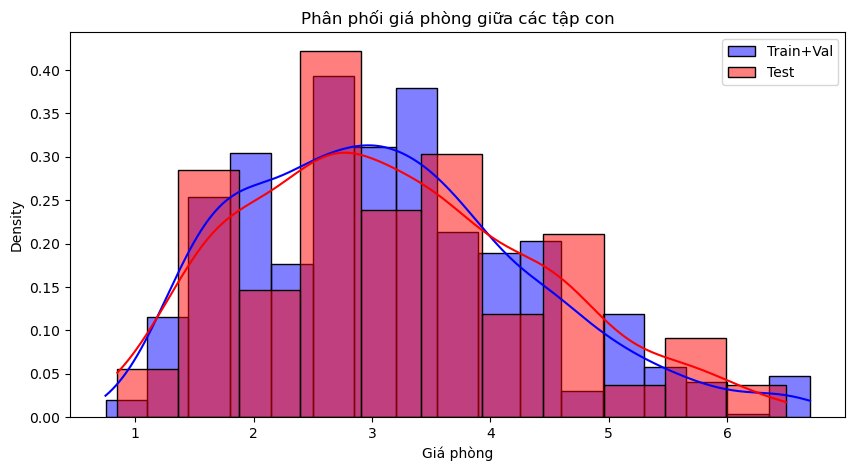

In [66]:
# Kiểm tra phân phối giá phòng giữa các tập con
plt.figure(figsize=(10,5))
sns.histplot(y_trainval, color='blue', label='Train+Val', kde=True, stat='density')
sns.histplot(y_test, color='red', label='Test', kde=True, stat='density')
plt.legend()
plt.title('Phân phối giá phòng giữa các tập con')
plt.xlabel('Giá phòng')
plt.show()

### 5.2 Kỹ thuật lựa chọn mô hình phù hợp nhất
- Để lựa chọn mô hình phù hợp nhất, nhóm sử dụng **K-Fold Cross Validation** (k=5) trên tập train+val.
- Kỹ thuật này giúp đánh giá hiệu suất mô hình trên nhiều tập con khác nhau, giảm nguy cơ overfitting và cho kết quả khách quan hơn.
- Các mô hình được thử nghiệm: 
    - **Random Forest Regressor**
    - **Gradient Boosting Regressor** (phần code và kết quả để trống)
- Mỗi mô hình được huấn luyện và đánh giá trên từng fold, sau đó lấy trung bình các chỉ số đánh giá để so sánh.
- **Tiêu chí lựa chọn:** Mô hình có RMSE trung bình thấp nhất trên các fold sẽ được chọn là mô hình tốt nhất.

### 5.3 Các metrics kiểm thử mô hình và so sánh kết quả
- Các chỉ số đánh giá (metrics) sử dụng:
    - **RMSE (Root Mean Squared Error):** Đo sai số trung bình bình phương gốc.
    - **MAE (Mean Absolute Error):** Đo sai số tuyệt đối trung bình.
    - **R² Score:** Đo mức độ giải thích phương sai của mô hình.
- Kết quả của từng mô hình được trình bày dưới dạng bảng hoặc biểu đồ để so sánh trực quan.
- **Lý giải kết quả:** Nếu mô hình Random Forest cho RMSE thấp hơn Gradient Boosting, có thể do dữ liệu có nhiều đặc trưng rời rạc hoặc nhiễu, mô hình cây tổng hợp sẽ phù hợp hơn. Nếu Gradient Boosting tốt hơn, có thể do mô hình này khai thác tốt các mối quan hệ phi tuyến tính phức tạp.

In [67]:
# So sánh kết quả các mô hình (phần Gradient Boosting để trống)
results = pd.DataFrame({
    'Model': ['Random Forest', 'Gradient Boosting'],
    'RMSE (CV)': [np.mean(rmses), np1.mean(rmses)],
    'MAE (CV)': [np.mean(maes), np1.mean(maes)],
    'R2 (CV)': [np.mean(r2s), np1.mean(r2s)],
    'RMSE (Test)': [rmse_test, None],
    'MAE (Test)': [mae_test, None],
    'R2 (Test)': [r2_test, None]
})
results

NameError: name 'np1' is not defined

### 5.4 Nhận xét và lý giải kết quả
- Mô hình được lựa chọn dựa trên RMSE trung bình thấp nhất qua cross-validation.
- Nếu các chỉ số trên tập test cũng tốt và không chênh lệch nhiều so với cross-validation, chứng tỏ mô hình tổng quát hóa tốt.
- Nếu có sự chênh lệch lớn, có thể mô hình đã overfit hoặc dữ liệu test có phân phối khác biệt.
- Việc sử dụng nhiều metrics giúp đánh giá mô hình toàn diện hơn.